demonstration using random points

In [1]:
import numpy as np
import pandas as pd 
import geopandas as gpd 
from shapely.geometry import Point  #, Polygon
from sklearn.neighbors import KernelDensity  # for KDE calculation (week 6)

from sklearn.cluster import KMeans  # for K-means clustering calculation (week 7)
from sklearn.metrics.pairwise import pairwise_distances_argmin  # [k-means] for finding which center each point is following (belongs to)
from sklearn.cluster import DBSCAN  # for dbscan calculation (week 7)
from scipy import spatial  # for the kd-tree (see week 5): https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.KDTree.html 

from sklearn.datasets import make_blobs  # for creating random demo clusters

from scipy.spatial.distance import cdist  # distortion calculation

# for plotting
import matplotlib.pyplot as plt 
import seaborn as sns
from matplotlib_scalebar.scalebar import ScaleBar  # https://pypi.org/project/matplotlib-scalebar/

# custom script of functions
from utils_week05 import gen_grid  # for the grid for calculating kde
from utils_week07 import run_kmeans, run_voronoi, run_std_ellipse, run_convex_hull  # for k-means

## create clustered points (random)

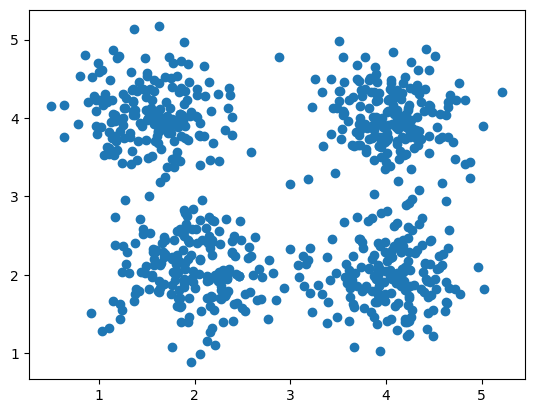

In [9]:
## random_state is the random seed

centers = [[4, 4], [2, 2], [4, 2], [1.5, 4]]
pts, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=1
)
plt.scatter(pts[:, 0], pts[:, 1])

In [12]:
# see how the data looks like
print(pts.shape)
pts  # two columns of coordinates, first x, second y


(750, 2)


array([[1.9324372 , 4.68975669],
       [1.32824561, 3.81016405],
       [1.74121436, 4.12577277],
       ...,
       [1.9394754 , 4.46128505],
       [2.1800871 , 2.25097483],
       [4.37405911, 2.72501113]])

<Axes: >

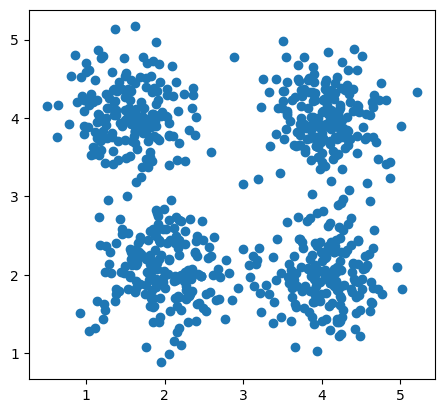

In [13]:
pts_df = pd.DataFrame.from_dict({
    'id': list(range(750)), 
    'x': pts[:,0], 
    'y': pts[:,1],
    'geometry': [Point(x,y) for x,y in zip(pts[:,0], pts[:,1])]
})

pts_gdf = gpd.GeoDataFrame(pts_df, geometry=pts_df['geometry'], crs=None)
pts_gdf.plot()

## generate grid for KDE (week 6)

In [14]:
xmin = min(pts[:,0])
xmax = max(pts[:,0])
ymin = min(pts[:,1])
ymax = max(pts[:,1])

xlim = [xmin, xmax]
ylim = [ymin, ymax]

In [6]:
xmin, ymin, xmax, ymax

(0.3021548559089524, 0.7815427780800293, 5.268389909316072, 5.057174288405896)

4.711627930652678 4.283322067826782
48 43 2064


100%|█████████████████████████████████████████████████████| 2064/2064 [00:00<00:00, 92963.54it/s]


<Axes: >

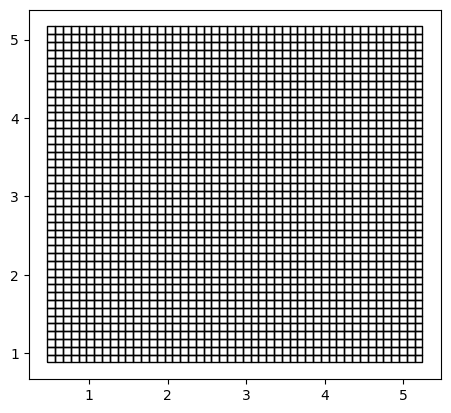

In [15]:
size = .1
len_x = xmax - xmin
len_y = ymax - ymin

print(len_x, len_y)

ncol = int(np.ceil(len_x/size))
nrow = int(np.ceil(len_y/size))
print(ncol, nrow, ncol*nrow)

grid = gen_grid(xmin, ymin, xmax, ymax, ncol=ncol, nrow=nrow, force_square=True, crs=None)
cent = grid.centroid
grid['x'] = cent.x
grid['y'] = cent.y
grid.plot(fc='none', ec='k')

In [16]:
grid_data = grid[['x', 'y']]
grid_data = np.array(grid_data)
grid_data, grid_data.shape

(array([[0.51564356, 0.93340751],
        [0.6152557 , 0.93340751],
        [0.71486785, 0.93340751],
        ...,
        [4.99818991, 5.11711743],
        [5.09780205, 5.11711743],
        [5.1974142 , 5.11711743]]),
 (2064, 2))

## calculate KDE and plotting (week 6)

In [17]:
demo_kde = KernelDensity(kernel='exponential', bandwidth=.4).fit(pts)
grid['dens'] = np.exp(demo_kde.score_samples(grid_data))

demo_kde

KernelDensity(bandwidth=0.4, kernel='exponential')

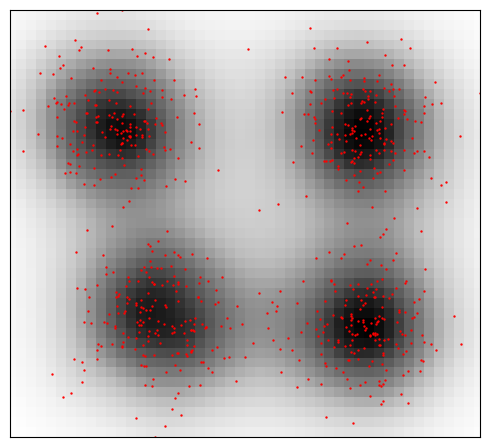

In [18]:

fig, ax = plt.subplots(figsize=(5,5))

grid.plot('dens', cmap='Greys', ax=ax)

#ax.scatter(pts[:, 0], pts[:, 1], marker='.', s=1, c='r')
pts_gdf.plot(marker='.', markersize=2, c='r', ax=ax)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()

## run k-means

In [48]:
k_means = KMeans(init="k-means++", n_clusters=5, n_init=10)
k_means.fit(pts)
k_means

KMeans(n_clusters=5, n_init=10)

In [49]:
k_means_cluster_centers = k_means.cluster_centers_
k_means_cluster_centers

array([[4.04302968, 4.00707562],
       [1.73598021, 2.21246826],
       [4.08009215, 1.99857761],
       [1.54981049, 4.05280381],
       [2.41909978, 1.83519709]])

In [50]:
k_means_labels = pairwise_distances_argmin(pts, k_means_cluster_centers)
k_means_labels, k_means_labels.shape

(array([3, 3, 3, 3, 0, 1, 0, 0, 1, 3, 1, 2, 0, 1, 4, 1, 0, 2, 2, 4, 3, 1,
        4, 1, 3, 3, 1, 4, 3, 1, 1, 2, 2, 1, 0, 0, 2, 2, 1, 0, 0, 4, 2, 0,
        1, 2, 1, 1, 2, 2, 1, 0, 4, 0, 2, 3, 3, 0, 2, 2, 3, 3, 2, 3, 0, 1,
        1, 1, 2, 4, 1, 0, 0, 1, 0, 0, 2, 3, 3, 1, 2, 0, 4, 0, 3, 1, 0, 4,
        0, 3, 3, 1, 3, 4, 2, 2, 0, 0, 4, 3, 3, 2, 3, 0, 1, 0, 0, 2, 0, 0,
        0, 3, 1, 3, 3, 2, 1, 3, 0, 3, 3, 3, 3, 0, 3, 2, 0, 3, 4, 3, 0, 2,
        3, 0, 4, 0, 2, 1, 1, 0, 4, 2, 3, 1, 2, 4, 2, 1, 2, 2, 0, 1, 2, 2,
        4, 2, 2, 3, 0, 0, 2, 0, 0, 2, 1, 3, 2, 0, 1, 2, 2, 0, 3, 3, 2, 4,
        4, 3, 0, 3, 2, 3, 1, 3, 0, 1, 0, 2, 2, 1, 2, 4, 0, 1, 2, 3, 3, 1,
        2, 3, 2, 3, 0, 2, 3, 0, 3, 0, 4, 2, 1, 1, 1, 1, 2, 4, 2, 3, 2, 0,
        0, 1, 3, 1, 0, 2, 0, 4, 4, 0, 2, 4, 1, 2, 2, 2, 1, 2, 0, 4, 3, 3,
        2, 0, 3, 0, 0, 3, 0, 3, 4, 3, 0, 2, 0, 0, 0, 1, 0, 1, 1, 4, 4, 0,
        0, 4, 0, 2, 0, 3, 3, 4, 3, 0, 3, 3, 2, 4, 0, 3, 3, 2, 2, 3, 0, 3,
        4, 1, 2, 3, 1, 0, 2, 0, 2, 0, 

In [51]:
pts_gdf['kmeans_label'] = k_means_labels

pts_gdf.head()

,id,x,y,geometry,kmeans_label,kmeans_color
0,0,1.932437,4.689757,POINT (1.93244 4.68976),3,"(0.9333333333333333, 0.5215686274509804, 0.290..."
1,1,1.328246,3.810164,POINT (1.32825 3.81016),3,"(0.9333333333333333, 0.5215686274509804, 0.290..."
2,2,1.741214,4.125773,POINT (1.74121 4.12577),3,"(0.9333333333333333, 0.5215686274509804, 0.290..."
3,3,1.711180,3.375552,POINT (1.71118 3.37555),3,"(0.9333333333333333, 0.5215686274509804, 0.290..."
4,4,3.923266,3.644948,POINT (3.92327 3.64495),0,"(0.41568627450980394, 0.8, 0.39215686274509803)"


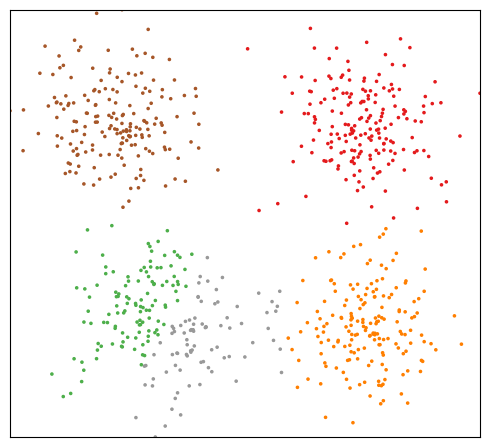

In [52]:

fig, ax = plt.subplots(figsize=(5,5))

#grid.plot('dens', cmap='Greys', ax=ax, alpha=.3)

pts_gdf.plot('kmeans_label', marker='.', markersize=10, ax=ax, cmap='Set1')

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()

In [27]:
clrs = sns.color_palette('muted')
clrs

clrs_dict = {k: clrs[k] for k in range(4)}  # list comprehension for dictionary

pts_gdf['kmeans_color'] = pts_gdf['kmeans_label'].map(clrs_dict)

clrs_dict, pts_gdf

({0: (0.2823529411764706, 0.47058823529411764, 0.8156862745098039),
  1: (0.9333333333333333, 0.5215686274509804, 0.2901960784313726),
  2: (0.41568627450980394, 0.8, 0.39215686274509803),
  3: (0.8392156862745098, 0.37254901960784315, 0.37254901960784315)},
       id         x         y                 geometry  kmeans_label  \
 0      0  1.932437  4.689757  POINT (1.93244 4.68976)             1   
 1      1  1.328246  3.810164  POINT (1.32825 3.81016)             1   
 2      2  1.741214  4.125773  POINT (1.74121 4.12577)             1   
 3      3  1.711180  3.375552  POINT (1.71118 3.37555)             1   
 4      4  3.923266  3.644948  POINT (3.92327 3.64495)             2   
 ..   ...       ...       ...                      ...           ...   
 745  745  3.717664  4.477074  POINT (3.71766 4.47707)             2   
 746  746  1.832425  1.808326  POINT (1.83242 1.80833)             3   
 747  747  1.939475  4.461285  POINT (1.93948 4.46129)             1   
 748  748  2.180087  

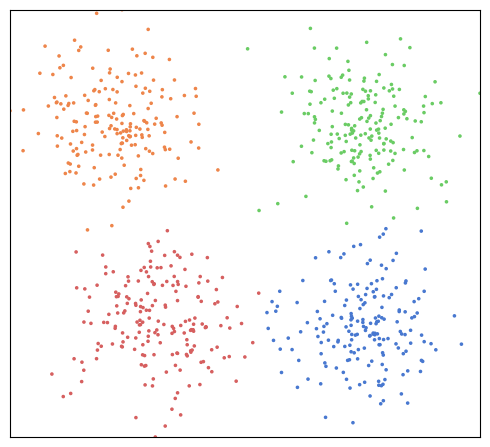

In [28]:

fig, ax = plt.subplots(figsize=(5,5))

#grid.plot('dens', cmap='Greys', ax=ax, alpha=.3)

pts_gdf.plot(color=pts_gdf['kmeans_color'], marker='.', markersize=10, ax=ax)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()

### generating Voronoi polygon using the custom function

In [30]:

centers = pd.DataFrame(k_means_cluster_centers, columns=['x', 'y'])
centers['k'] = list(range(len(k_means_cluster_centers)))
centers = centers[['k', 'x', 'y']]
centers = gpd.GeoDataFrame(centers, 
                           geometry=[Point(x, y) for i, (x, y) in centers[['x', 'y']].iterrows()], 
                           crs=None)
centers

,k,x,y,geometry
0,0,4.040163,1.997720,POINT (4.04016 1.99772)
1,1,1.548195,4.041280,POINT (1.54820 4.04128)
2,2,4.043030,4.007076,POINT (4.04303 4.00708)
3,3,1.980633,2.048293,POINT (1.98063 2.04829)


In [31]:
clrs = sns.color_palette('pastel')
clrs

[(0.6313725490196078, 0.788235294117647, 0.9568627450980393),
 (1.0, 0.7058823529411765, 0.5098039215686274),
 (0.5529411764705883, 0.8980392156862745, 0.6313725490196078),
 (1.0, 0.6235294117647059, 0.6078431372549019),
 (0.8156862745098039, 0.7333333333333333, 1.0),
 (0.8705882352941177, 0.7333333333333333, 0.6078431372549019),
 (0.9803921568627451, 0.6901960784313725, 0.8941176470588236),
 (0.8117647058823529, 0.8117647058823529, 0.8117647058823529),
 (1.0, 0.996078431372549, 0.6392156862745098),
 (0.7254901960784313, 0.9490196078431372, 0.9411764705882353)]

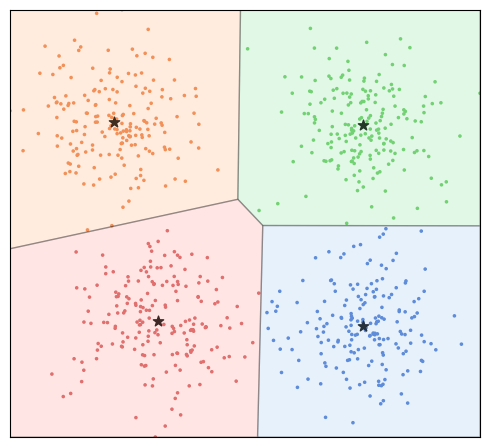

In [33]:

vor_gdf = run_voronoi(centers, xmin, ymin, xmax, ymax)

fig, ax = plt.subplots(figsize=(5,5))

vor_gdf.plot(fc=[clrs[k] for k in vor_gdf['k']], 
             alpha=0.25, ec='k',
             zorder=2, ax=ax)

pts_gdf.plot(color=pts_gdf['kmeans_color'], marker='.', markersize=10, ax=ax)

centers.plot(ax=ax, marker='*', markersize=60, c='k')

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()

## k-means: selecting k using elbow method

In [35]:
K = range(1, 16)
list(K)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

In [36]:
random_state = 42  # random seed


# Initialize lists to store distortion and inertia values
distortions = []
inertias = []
mapping1 = {}
mapping2 = {}

# Fit K-means for different values of k
for k in K:
    #kmeanModel = KMeans(n_clusters=k, random_state=42).fit(X)
    k_means = KMeans(init="k-means++", n_clusters=k, n_init=10, random_state=random_state)
    k_means.fit(pts)
    
    # Calculate distortion as the average squared distance from points to their cluster centers
    distortions.append(sum(np.min(cdist(pts, k_means.cluster_centers_, 'euclidean'), axis=1)**2) / pts.shape[0])
    
    # Inertia is calculated directly by KMeans
    inertias.append(k_means.inertia_)

res = pd.DataFrame.from_dict({'k': K, 'distortion': distortions, 'inertia': inertias})
res

,k,distortion,inertia
0,1,2.622453,1966.839569
1,2,1.327966,995.974832
2,3,0.793431,595.073172
3,4,0.304633,228.474929
4,5,0.270430,202.822314
5,6,0.243860,182.895343
6,7,0.218992,164.244064
7,8,0.197860,148.395247
8,9,0.178386,133.789342
9,10,0.163059,122.294303


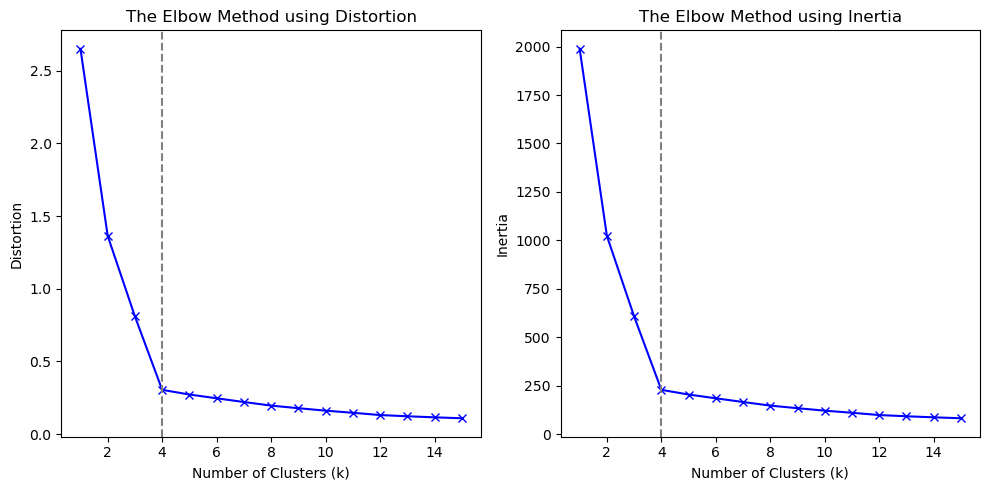

In [22]:

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
ax0, ax1 = axs
ax0.plot(K, res['distortion'], 'bx-')
ax0.set_xlabel('Number of Clusters (k)')
ax0.set_ylabel('Distortion')
ax0.set_title('The Elbow Method using Distortion')

ax1.plot(K, res['inertia'], 'bx-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('The Elbow Method using Inertia')

for ax in axs:
    ax.axvline(x=4, ls='--', c='grey')
plt.tight_layout()


## for DBSCAN 

In [53]:
pts_gdf

,id,x,y,geometry,kmeans_label,kmeans_color
0,0,1.932437,4.689757,POINT (1.93244 4.68976),3,"(0.9333333333333333, 0.5215686274509804, 0.290..."
1,1,1.328246,3.810164,POINT (1.32825 3.81016),3,"(0.9333333333333333, 0.5215686274509804, 0.290..."
2,2,1.741214,4.125773,POINT (1.74121 4.12577),3,"(0.9333333333333333, 0.5215686274509804, 0.290..."
3,3,1.711180,3.375552,POINT (1.71118 3.37555),3,"(0.9333333333333333, 0.5215686274509804, 0.290..."
4,4,3.923266,3.644948,POINT (3.92327 3.64495),0,"(0.41568627450980394, 0.8, 0.39215686274509803)"
...,...,...,...,...,...,...
745,745,3.717664,4.477074,POINT (3.71766 4.47707),0,"(0.41568627450980394, 0.8, 0.39215686274509803)"
746,746,1.832425,1.808326,POINT (1.83242 1.80833),1,"(0.8392156862745098, 0.37254901960784315, 0.37..."
747,747,1.939475,4.461285,POINT (1.93948 4.46129),3,"(0.9333333333333333, 0.5215686274509804, 0.290..."
748,748,2.180087,2.250975,POINT (2.18009 2.25097),1,"(0.8392156862745098, 0.37254901960784315, 0.37..."


In [54]:

db_a = DBSCAN(eps=0.3, min_samples=10).fit(pts)
db_a

DBSCAN(eps=0.3, min_samples=10)

In [55]:
db_a.labels_

array([ 0,  0,  0,  0,  1,  2,  1,  1,  2,  0,  2,  3,  1,  2,  2,  2,  1,
       -1,  3,  2,  0,  2,  2,  2,  0,  0,  2,  2,  0,  2,  2,  3,  3,  2,
        1,  1,  3,  3,  2,  1,  1,  3,  3,  1,  2,  3,  2,  2,  3,  3,  2,
        1,  2,  1,  3,  0,  0,  1,  3,  3,  0,  0,  3,  0,  1,  2,  2,  2,
        3,  2,  2, -1,  1,  2,  1,  1,  3,  0,  0,  2,  3, -1,  2, -1,  0,
        2,  1,  2,  1,  0,  0,  2,  0,  2,  3,  3,  1,  1,  3,  0,  0,  3,
        0,  1,  2,  1,  1,  3,  1,  1,  1,  0,  2,  0,  0,  3,  2,  0,  1,
        0,  0,  0,  0,  1,  0,  3, -1,  0,  2,  0,  1,  3,  0,  1,  2,  1,
        3,  2,  2,  1, -1,  3,  0,  2,  3,  2,  3, -1,  3,  3,  1,  2,  3,
        3,  2,  3,  3,  0,  1,  1,  3,  1,  1,  3,  2,  0,  3,  1,  2,  3,
        3,  1,  0,  0,  3,  2,  2,  0,  1,  0,  3,  0,  2,  0,  1,  2,  1,
        3,  3,  2,  3,  2,  1,  2,  3,  0,  0,  2,  3,  0, -1,  0,  1,  3,
        0,  1,  0,  1,  3,  3,  2,  2,  2, -1,  3,  2,  3,  0,  3,  1,  1,
        2,  0,  2,  1,  3

In [56]:
pts_gdf['dbscan_label'] = db_a.labels_

In [57]:

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(db_a.labels_)) - (1 if -1 in db_a.labels_ else 0)
n_noise_ = list(db_a.labels_).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 4
Estimated number of noise points: 28


In [58]:
clrs = sns.color_palette('muted')
clrs_dict = {k: clrs[k] for k in range(4)}
clrs_dict.update({-1: 'k'})

pts_gdf['dbscan_color'] = pts_gdf['dbscan_label'].map(clrs_dict)

clrs_dict

{0: (0.2823529411764706, 0.47058823529411764, 0.8156862745098039),
 1: (0.9333333333333333, 0.5215686274509804, 0.2901960784313726),
 2: (0.41568627450980394, 0.8, 0.39215686274509803),
 3: (0.8392156862745098, 0.37254901960784315, 0.37254901960784315),
 -1: 'k'}

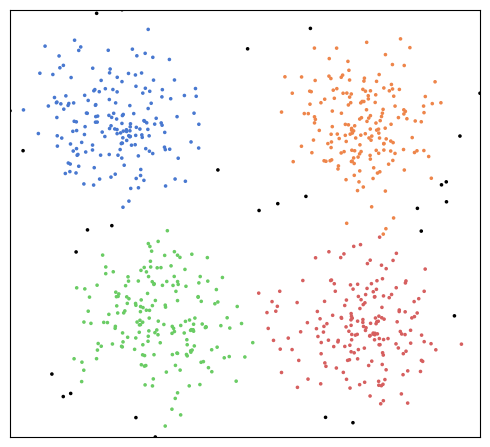

In [59]:

fig, ax = plt.subplots(figsize=(5,5))

#grid.plot('dens', cmap='Greys', ax=ax, alpha=.3)

pts_gdf.plot(color=pts_gdf['dbscan_color'], marker='.', markersize=10, ax=ax,)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()

In [60]:
pts_gdf

,id,x,y,geometry,kmeans_label,kmeans_color,dbscan_label,dbscan_color
0,0,1.932437,4.689757,POINT (1.93244 4.68976),3,"(0.9333333333333333, 0.5215686274509804, 0.290...",0,"(0.2823529411764706, 0.47058823529411764, 0.81..."
1,1,1.328246,3.810164,POINT (1.32825 3.81016),3,"(0.9333333333333333, 0.5215686274509804, 0.290...",0,"(0.2823529411764706, 0.47058823529411764, 0.81..."
2,2,1.741214,4.125773,POINT (1.74121 4.12577),3,"(0.9333333333333333, 0.5215686274509804, 0.290...",0,"(0.2823529411764706, 0.47058823529411764, 0.81..."
3,3,1.711180,3.375552,POINT (1.71118 3.37555),3,"(0.9333333333333333, 0.5215686274509804, 0.290...",0,"(0.2823529411764706, 0.47058823529411764, 0.81..."
4,4,3.923266,3.644948,POINT (3.92327 3.64495),0,"(0.41568627450980394, 0.8, 0.39215686274509803)",1,"(0.9333333333333333, 0.5215686274509804, 0.290..."
...,...,...,...,...,...,...,...,...
745,745,3.717664,4.477074,POINT (3.71766 4.47707),0,"(0.41568627450980394, 0.8, 0.39215686274509803)",1,"(0.9333333333333333, 0.5215686274509804, 0.290..."
746,746,1.832425,1.808326,POINT (1.83242 1.80833),1,"(0.8392156862745098, 0.37254901960784315, 0.37...",2,"(0.41568627450980394, 0.8, 0.39215686274509803)"
747,747,1.939475,4.461285,POINT (1.93948 4.46129),3,"(0.9333333333333333, 0.5215686274509804, 0.290...",0,"(0.2823529411764706, 0.47058823529411764, 0.81..."
748,748,2.180087,2.250975,POINT (2.18009 2.25097),1,"(0.8392156862745098, 0.37254901960784315, 0.37...",2,"(0.41568627450980394, 0.8, 0.39215686274509803)"


Estimated number of clusters: 2
Estimated number of noise points: 15


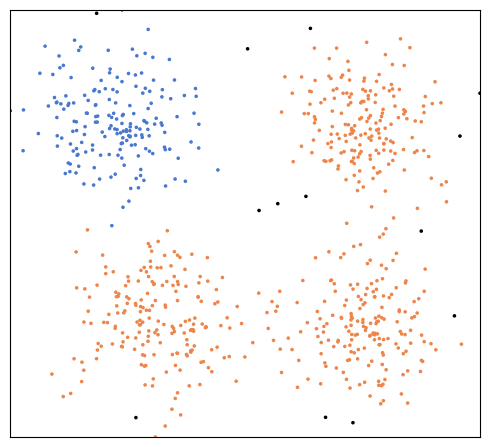

In [61]:

db_b = DBSCAN(eps=0.3, min_samples=5).fit(pts)
pts_gdf['dbscan_label_b'] = db_b.labels_


# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(db_b.labels_)) - (1 if -1 in db_b.labels_ else 0)
n_noise_ = list(db_b.labels_).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

clrs_dict = {k: clrs[k] for k in range(len(pts_gdf['dbscan_label_b'].unique()))}
clrs_dict.update({-1: 'k'})
pts_gdf['dbscan_color_b'] = pts_gdf['dbscan_label_b'].map(clrs_dict)


fig, ax = plt.subplots(figsize=(5,5))

pts_gdf.plot(color=pts_gdf['dbscan_color_b'], marker='.', markersize=10, ax=ax,)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()

Estimated number of clusters: 8
Estimated number of noise points: 145


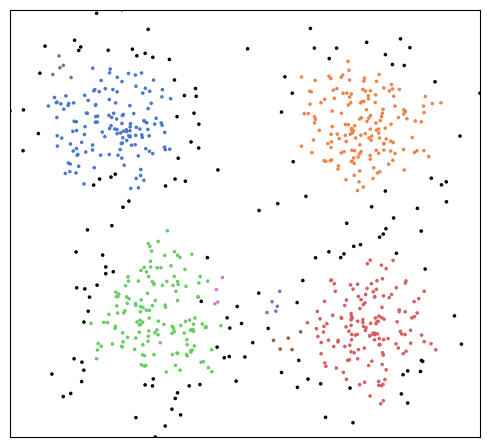

In [62]:

db_c = DBSCAN(eps=0.15, min_samples=5).fit(pts)
pts_gdf['dbscan_label_c'] = db_c.labels_


# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(db_c.labels_)) - (1 if -1 in db_c.labels_ else 0)
n_noise_ = list(db_c.labels_).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

clrs_dict = {k: clrs[k] for k in range(len(pts_gdf['dbscan_label_c'].unique()))}
clrs_dict.update({-1: 'k'})
pts_gdf['dbscan_color_c'] = pts_gdf['dbscan_label_c'].map(clrs_dict)


fig, ax = plt.subplots(figsize=(5,5))

pts_gdf.plot(color=pts_gdf['dbscan_color_c'], marker='.', markersize=10, ax=ax,)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()

### searching for the epsilon (distance)

using the k-nearest neighbor distance distribution

In [64]:
pts

array([[1.9324372 , 4.68975669],
       [1.32824561, 3.81016405],
       [1.74121436, 4.12577277],
       ...,
       [1.9394754 , 4.46128505],
       [2.1800871 , 2.25097483],
       [4.37405911, 2.72501113]])

In [65]:
tree = spatial.KDTree(pts)

In [66]:
min_samples = 4
dd, ii = tree.query(pts, k=min_samples)
dd, ii

(array([[0.        , 0.08669043, 0.16077404, 0.16750593],
        [0.        , 0.04935419, 0.09763071, 0.11217519],
        [0.        , 0.08918588, 0.10576948, 0.10757508],
        ...,
        [0.        , 0.11564026, 0.11829734, 0.13029428],
        [0.        , 0.09433699, 0.13134607, 0.1368123 ],
        [0.        , 0.07859364, 0.18489684, 0.19107313]]),
 array([[  0, 440, 672, 172],
        [  1, 451, 275, 573],
        [  2, 490, 579, 743],
        ...,
        [747, 516, 554, 406],
        [748, 557, 617, 473],
        [749, 518, 640,  76]]))

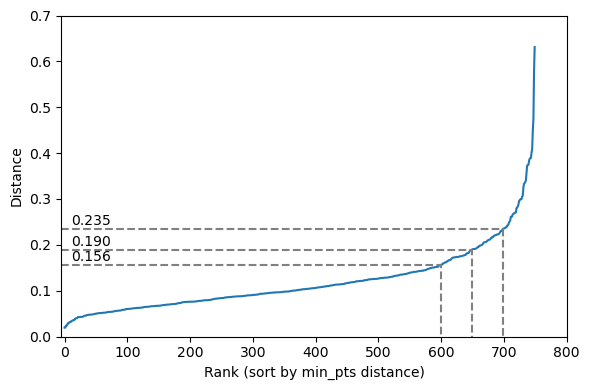

In [68]:
distance_to_min_samples = [d[-1] for d in dd]
distance_to_min_samples = sorted(distance_to_min_samples)

fig, ax = plt.subplots(figsize=(6,4))

ax.plot(list(range(len(distance_to_min_samples))), distance_to_min_samples)

minx = -5
dis = []
for rank in [600, 650, 700]:
    h = distance_to_min_samples[rank-1]
    ax.plot([minx, rank-1, rank-1], [h, h, 0], c='grey', ls='--')
    ax.text(10, h+.001, '{:.3f}'.format(h), ha='left', va='bottom')
    dis.append(h)

ax.set_xlabel('Rank (sort by min_pts distance)')
ax.set_ylabel('Distance')
ax.set_xlim([minx, 800])
ax.set_ylim([0, 0.7])
plt.tight_layout()

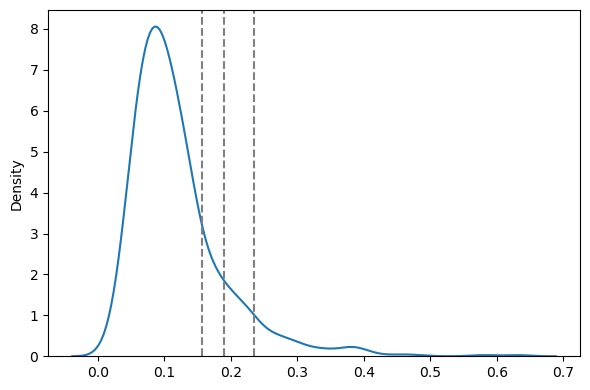

In [69]:
fig, ax = plt.subplots(figsize=(6,4))

sns.kdeplot(distance_to_min_samples)
for h in dis:
    ax.axvline(x=h, ls='--', c='grey')
plt.tight_layout()

In [70]:
total = len(distance_to_min_samples)
for d in dis:
    tmp = [v for v in distance_to_min_samples if v<=d]
    print('epsilon:', round(d, 3), ', non-core nodes percent:', round((total-len(tmp)) / total, 3))

# non-core = border + noise

epsilon: 0.156 , non-core nodes percent: 0.2
epsilon: 0.19 , non-core nodes percent: 0.133
epsilon: 0.235 , non-core nodes percent: 0.067


Estimated number of clusters: 3
Estimated number of noise points: 25


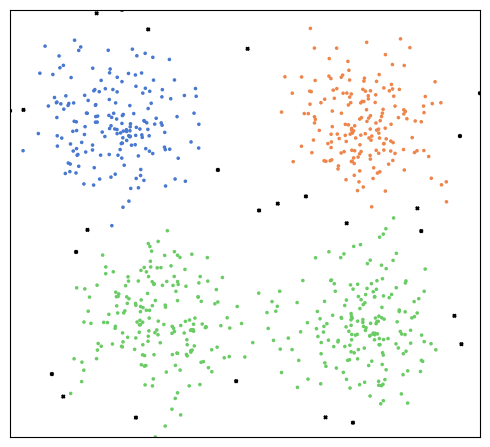

In [73]:

db_c = DBSCAN(eps=dis[-1], min_samples=4).fit(pts)
pts_gdf['dbscan_label_c'] = db_c.labels_


# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(db_c.labels_)) - (1 if -1 in db_c.labels_ else 0)
n_noise_ = list(db_c.labels_).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

clrs_dict = {k: clrs[k] for k in sorted(range(len(pts_gdf['dbscan_label_c'].unique()))) if k!=-1}
clrs_dict.update({-1: 'k'})
pts_gdf['dbscan_color_c'] = pts_gdf['dbscan_label_c'].map(clrs_dict)


fig, ax = plt.subplots(figsize=(5,5))

tmp1 = pts_gdf[pts_gdf['dbscan_label_c']!=-1]
tmp1.plot(color=tmp1['dbscan_color_c'], marker='.', markersize=10, ax=ax,)

tmp2 = pts_gdf[pts_gdf['dbscan_label_c']==-1]
tmp2.plot(color=tmp2['dbscan_color_c'], marker='x', markersize=5, ax=ax,)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()

In [72]:
25/750  # noise only

0.03333333333333333